# Austo - EXPLORATORY DATA ANALYSIS

## Table of Contents

### Navigation
- [Univariate Analysis](#univariate)
- [Bivariate Analysis](#bivariate)
- [Key Questions](#questions)
- [Actionable Insights and Business Recommendations](#insights)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('austo_automobile .csv')

In [3]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


## **Initial Diagnosis**

In [4]:
df.shape

(1581, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


> Total of 1581 rows and 14 columns of data with missing values in 'Gender' and 'Partner' salary
> 
> There are 4 numerical variables and 10 categorical variables

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1581.0,NaN,NaN,NaN,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
Gender,1528,4,Male,1199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,1581,2,Salaried,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_status,1581,2,Married,1443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1581,2,Post Graduate,985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_of_Dependents,1581.0,NaN,NaN,NaN,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Personal_loan,1581,2,Yes,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_loan,1581,2,No,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner_working,1581,2,Yes,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1581.0,NaN,NaN,NaN,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0


In [7]:
df[df['Total_salary'].quantile(0.75) <= df['Total_salary']]['Partner_working'].value_counts()

Partner_working
Yes    399
Name: count, dtype: int64

Top 25% Total_salary recorded in this dataset are of Customers with working partners. So, these are not treated as outliers. 

In [8]:
df['Partner_working'].value_counts()

Partner_working
Yes    868
No     713
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts(dropna=False)

Gender
Male      1199
Female     327
NaN         53
Femal        1
Femle        1
Name: count, dtype: int64

In [10]:
df['Partner_salary'].isnull().sum()

np.int64(106)

## Raw Insights from Initial Diagnosis

1. This dataset contains customers in the age group (22-54), average age of buyer being ~32 and typical age being 29.
2. Gender has 4 types since Female is spelt incorrectly - needs correction and also has NaN values, Male is the dominant category
3. ~56 % of the Customers are Salaried
4. ~91 % of the Customers are Married, indicating that data is heavily skewed towards 'family' buyers who generally prefer large/practical vehicles
5. ~62 % of the Customers are Post Graduate
6. Customers typically have 2 dependents
7. ~50 % of Customers have Personal Loan indicating that this may influence their purchase decisions
8. ~67% of Customers do not have House Loan indicating that this may influence their purchase decisions
9. ~ 55 % of the Customers have working partners which may also inlfuence purchase decisions
10. Typical Salary of a Customer is 59,500 USD
11. 7 % of the data in 'Partner_salary' is missing, check if there is a pattern for missing data
12. Combined Salary is typically 78,000 USD, with a significant gap between Median and Max indicating outliers
13. Price of Vehicle is typically 31k USD, with a significant gap between Median and Max indicating some Premium priced cars
14. ~44 % of the Make present in the dataset is 'Sedan', which dominates the dataset - check if it reveals a pattern

<a id="univariate"></a>
# Univariate Analysis

### Overview of Car Price and Make Preferences

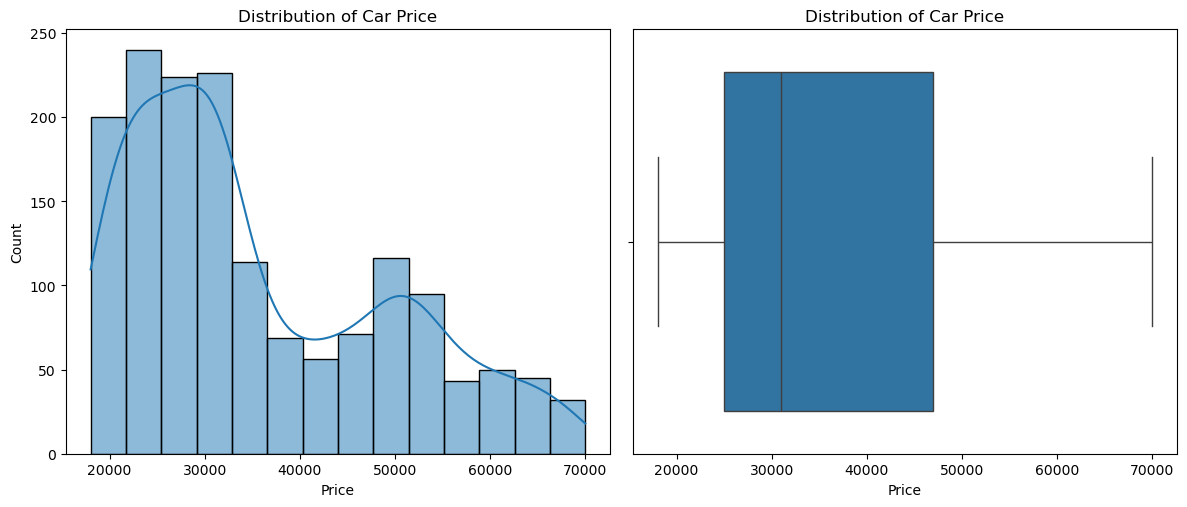

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(data=df, x='Price', ax=axes[0], kde=True);

sns.boxplot(data=df, x='Price', ax=axes[1]);

plt.tight_layout()

axes[0].set_title('Distribution of Car Price');
axes[1].set_title('Distribution of Car Price');

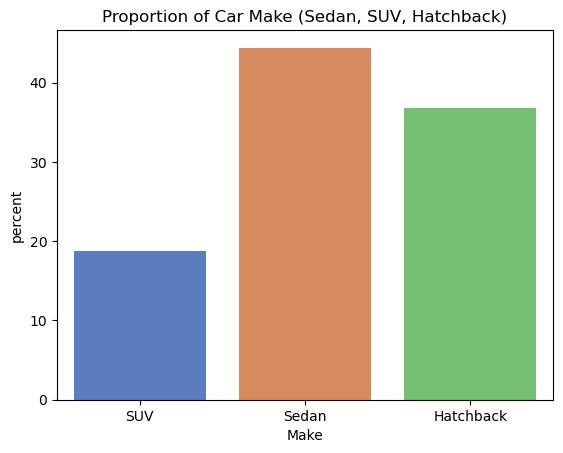

In [12]:
sns.countplot(data=df, x='Make', stat='percent', hue='Make', palette='muted')
plt.title('Proportion of Car Make (Sedan, SUV, Hatchback)');

###  *Insights* :

1. 50% of the cars fall in the price range 25k - 47k USD while higher priced cars are comparitively less in number stretch the long tail towards the right. This indicates that a significant portion of cars are present in the Mid segment.
2. Approximately 45% of the customers prefer Sedan in this dataset, followed by Hatchback (~ 35%)and SUV(~ 20%). This indicates that Sedans are the most commonly purchased car type followed by Hatchback. 

## Understanding the Customer base

### **Section 1: Customer Demographics**

### 1. Age

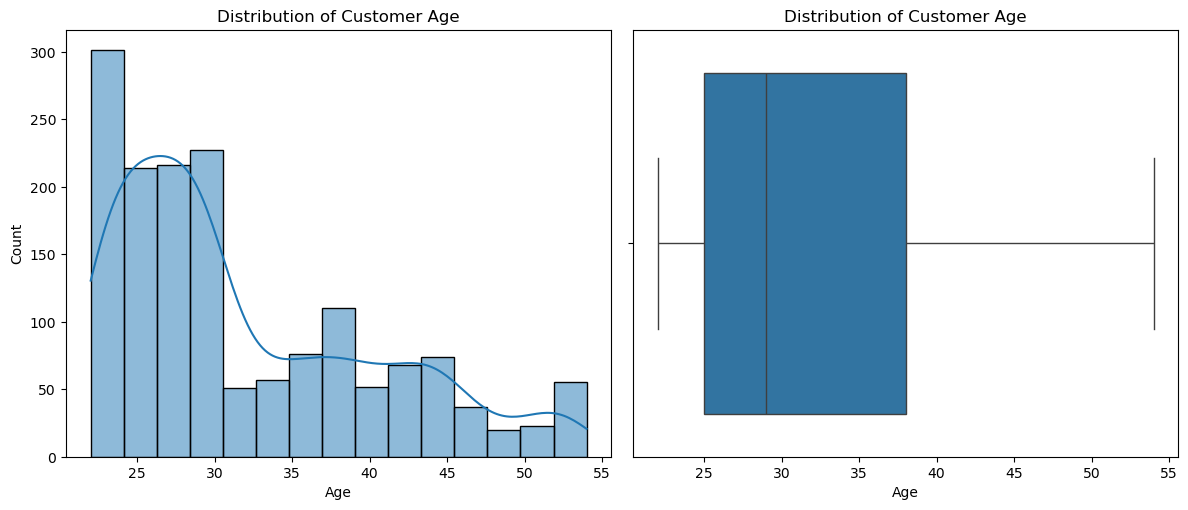

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(data=df, x='Age', kde=True, ax=axes[0])
sns.boxplot(data=df, x='Age', ax=axes[1])
plt.tight_layout()
axes[0].set_title('Distribution of Customer Age');
axes[1].set_title('Distribution of Customer Age');

Customers in this dataset are concentrated in the Age group 25-38. Beyond age 38, the older Age groups are more dispersed pulling the tail towards right, making this a right skewed distribution. 

This 25-38 age group could indicate first-time buyers or customers making family oriented purchase decisions - need to check if there is a purchase pattern.

> The older age groups' preferences and spending behaviour also needs further analysis. 



### 2. Gender

### Addressing the issues in gender column

In [14]:
df['Gender'].value_counts(dropna=False)

Gender
Male      1199
Female     327
NaN         53
Femal        1
Femle        1
Name: count, dtype: int64

In [15]:
# Correcting the inconsistent spelling

df['Gender'] = df['Gender'].replace(
    {
        'Femal' : 'Female',
        'Femle' : 'Female'
    }
)

In [16]:
df['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

### Since there are 53 NaN values, it makes sense to form a new category named 'Unknown' to avoid introducing bias into the dataset. 

### Unknown group represents missing data, so interpret with caution.

In [17]:
df['Gender'] = df['Gender'].fillna('Unknown')

In [18]:
df['Gender'].value_counts(dropna=False)

Gender
Male       1199
Female      329
Unknown      53
Name: count, dtype: int64

ValueError: Could not interpret value `Ged` for `hue`. An entry with this name does not appear in `data`.

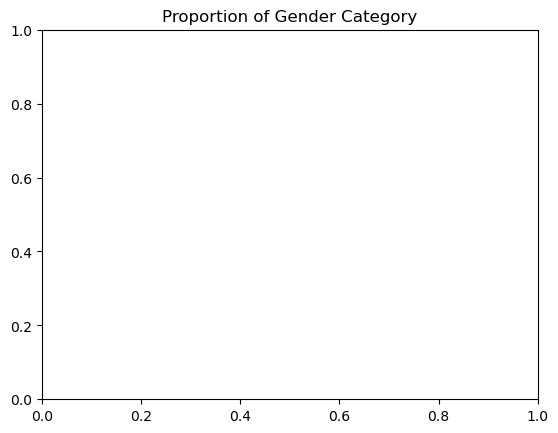

In [19]:
plt.title('Proportion of Gender Category')
sns.countplot(data=df, x='Gender', stat='percent', hue='Ged', palette='pastel');

### *Insights*

Approximately 75% of the customers are Male and 21% are Female, Unknown constitutes only 4% of the data. This dataset is heavily skewed towards male customers.

This implies that the insights derived will be more reflective of the male-behaviour in this dataset.

Since 'Unknown' only forms a small fraction, it is unlikely to distort trends.

However, check if unknown shows a preference for certain Make of cars or has a specific spending behaviour.

### 3. Number of Dependents

In [ ]:
sns.countplot(data=df, x='No_of_Dependents', stat='percent', hue='No_of_Dependents', palette='pastel')
plt.title('Distribution of No_of_Dependents');

~ 70% of the customers have >1 dependent suggesting that this dataset has a significant concentration of individuals with family responsibilities. 

> This may influence their preferences and purchase behaviour which needs further analysis. 

### 4. Marital Status

In [ ]:
sns.countplot(data=df, x='Marital_status', stat='percent', hue='Marital_status', palette='pastel')
plt.title('Marital Status of Customers');

~ 85% of the customers in this dataset are married suggesting that they are more likely to make family-oriented purchases

### **Section 2: Socio-economic Profile**

### 1. Profession

In [ ]:
sns.countplot(data=df, x='Profession', stat='percent', hue='Profession', palette='Set2')
plt.title('Professional Status of Customers');

Salaried Professionals are higher (~ 57 %) than business individuals (~43 %). 

> Profession can have an impact on individual preferences and spending behaviour- needs further analysis. 

### 2. Education

In [ ]:
sns.countplot(data=df, x='Education', stat='percent', hue='Education', palette='muted')
plt.title('Educational Status of Customers');

~ 63 % Customers are Postgraduates in the given dataset indicating a highly educated customer base.  


### 3. Person Loan Status

In [ ]:
sns.countplot(data=df, x='Personal_loan', stat='percent', hue='Personal_loan', palette='Set2')
plt.title('Personal Loan status of Customers');

This dataset provides an equal distribution of customers with and without Personal loan providing a balanced base for comparison. 


### 4. House Loan status

In [ ]:
sns.countplot(data=df, x='House_loan', stat='percent', hue='House_loan', palette='Set2')
plt.title('House Loan status of Customers');

Approximately 35% of the customers have House loan. Customers with a House Loan may have less disposable income which will impact their spending behaviour.

### 5. Partner Working Status

In [ ]:
sns.countplot(data=df, x='Partner_working', stat='percent', hue='Partner_working', palette='pastel')
plt.title('Proportion of Customers with Working Partners');

~ 55% of the Customers have working partners indicating the presence of Double-income households in the dataset. This suggests a higher purchasing power there by influencing the choice of Vehicles.

### **Section 3: Income Distribution**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(data=df, x='Salary', kde=True, ax=axes[0])

sns.boxplot(data=df, x='Salary', ax=axes[1]);

plt.tight_layout()

axes[0].set_title('Distribution of Customer Salaries')
axes[1].set_title('Distribution of Customer Salaries');

There are customers from varied salary ranges but 50% of them are concentrated in the range 52k - 72k USD


#### Addressing the missing values in Partner_salary

In [ ]:
df['Partner_salary'].isna().sum()

In [ ]:
df['Partner_salary'] = df['Partner_salary'].fillna(df['Total_salary'] - df['Salary'])

In [ ]:
df['Partner_salary'].isna().sum()

In [ ]:
df['Partner_working'].value_counts(normalize=True)

In [ ]:
# Considering working partners only
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df[df['Partner_working'] == 'Yes'], x='Partner_salary', kde=True, ax=axes[0])
sns.boxplot(data=df[df['Partner_working'] == 'Yes'], x='Partner_salary', ax=axes[1])

plt.tight_layout()
axes[0].set_title('Distribution of Partner Salary')
axes[1].set_title('Distribution of Partner Salary');

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df[df['Partner_working']== 'Yes'], x='Total_salary', kde=True, ax=axes[0])
sns.boxplot(data=df[df['Partner_working']== 'Yes'], x='Total_salary', ax=axes[1])

axes[0].set_title('Distribution of Total Salary of Customers with Working Partner')
axes[1].set_title('Distribution of Total Salary of Customers with Working Partner');

plt.tight_layout()

When considering only working partners, the salary distribution is centered around the mid-range, with a median around 32–35k USD and most values falling between approximately 28k and 40k USD. The distribution is slightly right-skewed, with a few high-income outliers extending up to 80k USD.

The distribution of Total Salary among Dual-income households is right skewed, with majority of customers falling in the mid-income range. A small number of high income households appear as outliers on the right, representing a premium segment with a much higher earning capacity. 

These values are retained as they reflect a typical variation in income in a urban demographic that uses cars, rather than data anomalies. 

### ***Summary - Univariate Analysis***

This dataset predominantly has customers who have purchased Sedans and Hatchbacks while SUVs constitute a relatively small share. A significant number purchases were made in the Mid-price segment. 

The customer base is more concentrated in the age group 25-38 and the gender distribution is more skewed towards Male. There were missing values in Gender column and has been renamed to Unknown. Even though it is a small sample size, it shall be interpreted with caution. 

A large part of the customer base is highly educated, married and with dependents suggesting a family oriented demographic. Salaried professionals form the majority compared to business customers, indicating a relatively stable income base. 

There are nearly equal number of customers with and without Personal loan providing a balanced base for analysis. Customers without homeloan are higher compared to customers with home loan indicating that loan adoption is present within the customer base. Additionaly, over half of the customers have working partners which indicates the presence of dual-income households. 

From a financial perspective, customers are typically distributed in a mid-income range with a small segment representing high income households. 

Overall, this dataset represents a young, urban, financially stable customer base with moderate to high income levels.


# Bivariate Analysis
<a id="bivariate"></a>

### **Section 1: Car Make vs Car Price**

In [ ]:
sns.boxplot(data=df, x='Make', y='Price', hue='Make', palette='muted')
plt.title('Car Price distribution by Make');

### Insights:

1. **SUVs** primarily occupy the **mid-to-premium** price segment, with higher median prices and a wider spread.
2. **Sedans** act as a **transitional segment**, overlapping with both hatchbacks and SUVs, while **hatchbacks** remain concentrated in the lower price range forming the **entry** segment

### **Section 2: Customer attributes vs Car Price**

### *Correlation of all the numeric variables*

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

1. Age shows the strongest correlation with car price (~0.80), indicating that customers tend to purchase higher-priced cars as they grow older. While income also influences price (Salary ~0.41, Total Salary ~0.37), its impact is comparatively moderate.

2. This suggests that car purchase decisions are not driven purely by affordability, but also by life stage and evolving preferences.

3. Partner income shows minimal correlation (~0.17), suggesting that dual-income households do not necessarily spend more on cars.

4. Number of Dependents show a negative correlation (-0.19) with Price of car indicating that customers tend to spend less on cars are family responsibilities increases. 

5. To better understand these relationships, further analysis needs to be done on specific customer segments.

### 1. Gender 

In [ ]:
df.groupby('Gender')['Price'].describe()

In [ ]:
sns.boxplot(data=df, x='Gender', y='Price', hue='Gender', palette='pastel')
plt.title('Distribution of Car Price across Gender');

> Male customers are concentrated in the low-mid price segment but contribute to a few high value outliers. Female customers are concentrated in the mid-high price segment. Typical spending levels among Female customers are higher in this dataset. 

### 2. Age

In [ ]:
# Segmenting Age into 4 groups based on quantiles

df.groupby(pd.qcut(df['Age'], q=4), observed=True)['Price'].describe()

> The mean and median car price progressively increases with age with a big leap after age 30. 

In [ ]:
sns.scatterplot(data=df, x='Age', y='Price')
plt.title('Relationship between Car Price and Customer Age')
plt.xlabel('Customer Age');

> There is an upward shift in Price with increase in Age. The scatterplot suggests a positive relationship between customer age and car price, with younger customers generally purchasing lower-priced vehicles and older customers showing a wider spread, including higher-priced cars.

### 3. Profession

In [ ]:
df.groupby('Profession')['Price'].describe()

In [ ]:
sns.boxplot(data=df, x='Profession', y='Price', hue='Profession', palette='Set2')
plt.title('Distribution of Car Price by Profession');

> Salaried customers spend slightly more than the Business Customers and also show a variable price range. Business customers are more concentrated in the ~23-41k Price segment with a few high value outliers indicating that Salaried customers show more varied spending patterns than business customers who are relatively more concentrated in the low-mid price segment. 

### 4. Education

In [ ]:
df.groupby('Education')['Price'].describe()

In [ ]:
sns.boxplot(data=df, x='Education', y='Price', hue='Education', palette='muted')
plt.title('Distribution of Car Price by Education');

> Education does not dramatically impact the spending behaviour. However, Graduates tend to show slightly more varied spending compared to Post Graduates.

### 5. Loan Status

In [ ]:
df.groupby('Personal_loan')['Price'].describe()

In [ ]:
df.groupby('House_loan')['Price'].describe()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Personal_loan', y='Price', ax=axes[0], hue='Personal_loan', palette='pastel')

sns.boxplot(data=df, x='House_loan', y='Price', ax=axes[1], hue='House_loan', palette='pastel')

plt.tight_layout()

axes[0].set_title('Distribution of Car Price by Personal Loan status')
axes[1].set_title('Distribution of Car Price by House Loan status');

> The distribution of car prices across customers with or without Personal loan is largely similar with nearly identical median and IQR. So, this does not appear to have an impact on spending behaviour.
>
> Customers with House loan tend to spend slightly less than the ones without House Loan. Customers without House loan have more varied spending behaviour but the core distribution overlaps, and the medians being so close suggests that, loan status is not a primary driver of purchasing behaviour.

### 6. Marital Status

In [ ]:
df.groupby('Marital_status')['Price'].describe()

In [ ]:
sns.boxplot(data=df, x='Marital_status', y='Price', hue='Marital_status', palette='pastel');
plt.title('Distribution of Car Price by Marital Status');

> The distribution of car prices across marital status shows significant overlap, with nearly identical medians for both groups. Married customers show a slightly wider spread in spending, but the overall similarity suggests that Marital status is not a strong driver in purchasing behaviour.

### 7. Partner Working status

In [ ]:
df.groupby('Partner_working')['Price'].describe()

In [ ]:
sns.boxplot(data=df, x='Partner_working', y='Price', hue='Partner_working', palette='pastel');
plt.title('Distribution of Car Price by Partner working Status');

> Despite dual-income households having a higher earning potential, the distribution shows a significant overlap with single-income households. This suggests that combined income alone does not automatically translate to purchasing cars from premium segment. This could be due factors such as loans or number of dependents.

### 8. Number of Dependents

In [ ]:
df.groupby('No_of_Dependents')['Price'].describe()

In [ ]:
sns.barplot(data=df, x='No_of_Dependents', y='Price', estimator='median', color='salmon')
plt.title('Distribution of Car Price with Number of Dependents');


In [ ]:
df[['No_of_Dependents', 'Price']].corr()

> Customers with one dependent show the highest median car price compared to other groups.
> No_of_Dependents is negatively correlated to Car Price indicating that customers tend to spend less on cars as family responsibility increases.

### **Section 3: Income Versus Car Price**

In [ ]:
# Segmenting customers by number of income sources

single_income = df[df['Partner_working'] == 'No'].copy()

single_income_corr = single_income[['Salary', 'Price']].corr()

single_income_corr

In [ ]:
dual_income = df[df['Partner_working'] == 'Yes'].copy()

dual_income_corr = dual_income[['Total_salary', 'Salary', 'Price']].corr()

dual_income_corr

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(single_income_corr, annot=True, ax=axes[0], cmap='viridis')
axes[0].set_title('Single Income')

sns.heatmap(dual_income_corr, annot=True, ax=axes[1], cmap='viridis')
axes[1].set_title('Dual Income');

>For single-income households, the correlation between salary and car price is moderate (0.38), indicating limited influence of individual income on purchasing behaviour.
>
>In contrast, for dual-income households, total household income shows a significantly stronger correlation with car price (0.62), compared to individual salary (0.43).
>
>>This suggests that purchasing decisions are more closely aligned with overall household earning capacity rather than individual income or employment status alone.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.regplot(data=single_income, x='Salary', y='Price', ax=axes[0])
axes[0].set_title('Single Income')

sns.regplot(data=dual_income, x='Total_salary', y='Price', ax=axes[1])
axes[1].set_title('Dual Income');

>The relationship between income and car price is significantly stronger and more consistent in dual-income households compared to single-income households. While single-income customers show a positive trend, their purchasing behaviour is far more dispersed, indicating the influence of additional factors beyond income.
> The noticeable spread across income levels in the car price range of 30k suggests that there is a strong preference for mid-segment cars.

In [ ]:
dual_income.shape

In [ ]:
single_income.shape

In [ ]:
df.groupby('Partner_working')['No_of_Dependents'].mean()

>Even though dual income households show a higher earning capacity, they have an average of ~ 2.5 dependents per household, which is slightly higher than that of single income households ( ~2.3). This suggests that, with increase in responsibilities, the spending capacity is diluted. Therefore, their higher earning capacity does not automatically translate to premium car purchases.

### *To better understand spending behaviour relative to income, a new variable 'relative_spending' is engineered as the ratio of car price to total household salary.*

In [ ]:
df['relative_spending'] = df['Price']/df['Total_salary']

In [ ]:
df.groupby('Partner_working')['relative_spending'].describe()

In [ ]:
sns.boxplot(data=df, x='Partner_working', y='relative_spending')
plt.title('Relative spending by Partner Working Status');

>Dual income households have a median relative spending of 0.35 compared to 0.57 for single income households indicating that dual-income customers spend proportionally less of their income on a car.  This suggests that dual-income customers are more financially disciplined likely because they have higher average dependents (~2.58 Vs 2.31) and broader financial responsibilities compared to single income customers.

In [ ]:
# Segmenting the Total_salary by Quantiles

labels=['Low', 'Mid', 'High', 'Very High']

df['income_level'] = pd.qcut(df['Total_salary'], q=4, labels=labels)

In [ ]:
df.head()

In [ ]:
sns.boxplot(data=df, x='income_level', y='Price')
plt.title('Car Price Distribution with Income Level');

Car price shows a clear upward trend across income levels, with median spending increasing consistently from low to very high income groups. This indicates that household income is a key driver of purchasing power. 

However, the presence of high value purchases even within lower income groups suggests that factors such as financing or aspirational buying also influence decisions.

### **Section 4: Car type preference across Segments**

### 1. Age groups

In [ ]:
age_pref = pd.crosstab(pd.cut(df['Age'], bins=[20,30,40,50,60]), df['Make'], normalize='index')

age_pref

In [ ]:
age_pref.plot(kind='bar', stacked=True)

plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

plt.title('Car Make Preference by Age Group')
plt.xticks(rotation=0);

> Car preferences evolve with age, with younger customers (20–30) predominantly choosing Hatchbacks, transitioning to Sedans in the 30–40 age group, and showing a higher inclination toward SUVs beyond 40. This indicates a shift from entry-level to premium segments as purchasing power and lifestyle needs evolve.
>
> 50-60 age group represents a small sample size, must be interpreted with caution.

### 2. Gender

In [ ]:
gender_make = pd.crosstab(df['Gender'], df['Make'], normalize='index')
gender_make

In [ ]:
gender_make.plot(kind='bar', stacked=True)

plt.title('Car type Preference by Gender');
plt.ylabel('Share of Customers')
plt.xticks(rotation=0)
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

> Female customers tend to prefer SUVs more compared to Male customers while Male show a stronger inclination towards Hatchbacks and Sedans. 

> Large portion of the Unknown group are Sedan buyers. 

### 3. Profession and Education

In [ ]:
prof_make = pd.crosstab(df['Profession'], df['Make'], normalize='index')
prof_make

In [ ]:
prof_make.plot(kind='bar', stacked=True)
plt.title('Car Preference by Profession');
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

> Approximately 44% of salaried customers prefer sedans, making it the most common vehicle type within this group.

In [ ]:
edu_make = pd.crosstab(df['Education'], df['Make'], normalize='index')
edu_make

In [ ]:
edu_make.plot(kind='bar', stacked=True)
plt.title('Car Preference by Education');
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

>Profession introduces mild variation in car type preference, with business customers leaning toward Hatchbacks and salaried customers toward SUVs, while Sedans maintain consistent popularity across both segments.
>
> Sedan emerges as the most commonly preferred car type across all education levels, indicating its broad appeal across customer segments.


### 4. Income Level

In [ ]:
income_make = pd.crosstab(df['income_level'], df['Make'], normalize='index')
income_make

In [ ]:
income_make.plot(kind='bar', stacked=True)

plt.title('Car Preference by Income Level');
plt.ylabel('Proportion')
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

> Hatchback preference declines consistently with increasing income, while SUV preference rises, indicating a shift from entry-level to premium segments. Sedan purchases remain relatively stable across all income groups, acting as a mid-segment option that appeals broadly irrespective of income.
>
> Income drives the upgrade path.
> Sedans continue to retain a strong presence even in higher income groups, indicating that they remain a practical and widely acceptable choice.

### 4. Number of Dependents

In [ ]:
dep_make = pd.crosstab(df['No_of_Dependents'], df['Make'], normalize='index')
dep_make

In [ ]:
dep_make.plot(kind='bar', stacked=True)

plt.ylabel('Proportion')

plt.title('Car Type Preference by Number of Dependents')
plt.xticks(rotation=0);
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

> SUV preference does not increase with the increase in number of dependents. 

> Hatchback Preference peaks at extreme ends of the dependent range. 

> Sedan is prefered among customers with 1-2 dependents, noticeably dropping when the dependents increase. 

 > This suggests the affordabililty and financial obligations plays a significant role in the car type 

### 5. Marital Status

In [ ]:
mar_make = pd.crosstab(df['Marital_status'], df['Make'], normalize='index')
mar_make

In [ ]:
mar_make.plot(kind='bar', stacked=True)

plt.ylabel('Proportion')

plt.title('Car Type Preference by Marital_status')
plt.xticks(rotation=0);
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

> Marital status shows a noticeable difference in car type distribution, with single customers skewed toward Hatchbacks and married customers showing a stronger preference for Sedans. However, since single customers form a small proportion of the dataset, these observations should be interpreted with caution.

### 6. Loan Status

In [ ]:
hloan_make = pd.crosstab(df['House_loan'], df['Make'], normalize='index')
hloan_make

In [ ]:
ploan_make = pd.crosstab(df['Personal_loan'], df['Make'], normalize='index')
ploan_make

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# House Loan
hloan_make.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Car Type Distribution by House Loan')
axes[0].set_xlabel('House Loan')
axes[0].set_ylabel('Proportion')

# Personal Loan
ploan_make.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Car Type Distribution by Personal Loan')
axes[1].set_xlabel('Personal Loan')


plt.tight_layout()
plt.show()

> Customers with a house loan show a significantly lower preference for SUVs and a higher inclination toward Hatchbacks and Sedans, indicating the impact of long-term financial commitments on purchase decisions.
>
> In contrast, personal loan status shows only a mild influence, with a slight reduction in SUV preference and increased inclination toward Sedans.

### 7. Partner Working

In [ ]:
pwstatus_make = pd.crosstab(df['Partner_working'], df['Make'], normalize='index')
pwstatus_make

In [ ]:
pwstatus_make.plot(kind='bar', stacked=True)
plt.xticks(rotation=0)
plt.title('Car type Preference by Partner working Status');
plt.ylabel('Proportion');
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False)

> Partner working status shows a mild influence on car type preference, with dual-income households exhibiting a higher inclination toward Sedans, while single-income households are slightly more distributed across Hatchbacks and SUVs.

###  ***Summary- BIVARIATE/MULTIVARIATE ANALYSIS***

Customer purchasing behaviour in this dataset is primarily driven by age and then income, which together determine the price segment of the car chosen. As income increases, customers move away from Hatchbacks, indicating a clear upgrade path, although the transition toward SUVs is gradual. 

Sedans consistently emerge as the most preferred option across income levels, acting as a balanced mid-segment choice. Similarly, with increasing age, customers show a tendency to shift toward higher-priced vehicles, reflecting evolving lifestyle and purchasing capacity.

Gender exhibits a noticeable influence on car type preference, with female customers showing a higher inclination toward SUVs, while male customers predominantly prefer Hatchbacks and Sedans. However, this observation should be interpreted with caution due to differences in sample size.

Financial commitments such as loans do not significantly alter overall car type preference but reinforce the dominance of Hatchbacks and Sedans over SUVs. Similarly, variables like partner working status and profession introduce only mild variations, with no strong shift toward premium segments even among dual-income households. Sedans remain consistently preferred across these segments.

## *KEY QUESTIONS*
<a id="questions"></a>

## 1. Do men tend to prefer SUVs more compared to women?

### *No, Men do not tend to prefer SUVs more compared to women.* 

In this dataset, male customers are more inclined toward Hatchbacks and Sedans, while female customers show a significantly higher preference for SUVs.

Specifically, ~52% of female customers purchase SUVs compared to only ~10% of male customers, indicating that women are substantially more likely to opt for SUVs than men.

In [ ]:
gender_make = pd.crosstab(df['Gender'], df['Make'], normalize='index')
gender_make

## 2. What is the likelihood of a salaried person buying a Sedan?

### *The likelihood of a salaried person buying a Sedan is approximately 44%.*

This indicates that Sedans are the most preferred car type among Salaried customers, slightly higher than Hatchbacks (~ 32 %) and significantly higher than SUVs (~ 23 % )

This shows Salaried customers tend to favour mid-price segment that balance affordability and balance rather than premium-price segment.

In [ ]:
pd.crosstab(df['Profession'], df['Make'], normalize='index')

## 3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?

### **The data does not support Sheldon Cooper’s claim.**

Among salaried male customers, only ~13% purchase SUVs, while ~44% opt for Sedans. This indicates that salaried males are significantly more inclined towards Sedans rather than SUVs, making them a weaker target segment for SUV sales.

In essence, the claim is contradicted by data.

In [ ]:
sheldon_claim = pd.crosstab(
    [df['Profession'], df['Gender']], 
    df['Make'], 
    normalize='index'
)
sheldon_claim

In [ ]:
sheldon_claim.plot(kind='bar', stacked=True)
plt.title('Distribution of Make, given Profession and Gender');
plt.xticks(rotation=45, ha='right');
plt.xlabel('Profession, Gender');
plt.ylabel('Proportion of Car Make')
plt.legend(title='Make',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False);

## 4. How does the amount spent on purchasing automobiles vary by gender?

### *A typical female customer spent substantially higher on car compared to a typical Male customer.*

The median price spent by a Female customer is 49k USD while a Male typically spent 29k USD indicating a noticeable difference in spending patterns. However, the Female customer sample size is significantly small compared to Male customers, so this observation should be interpreted with caution. 

In [ ]:
df.groupby('Gender')['Price'].describe()

## 5. How much money was spent on purchasing automobiles by individuals who took a personal loan?

### *Individuals with a personal loan spent a total of 27.3M USD, accounting for 48.5% of the dealership's total revenue.*

On an individual basis, they spent an average of ~$31k, which is consistent with cash buyers. This indicates that personal loan status does not significantly influence car purchase spending. Instead, purchasing behaviour appears to be driven more by overall affordability than by loan dependency.

In [ ]:
print("Amount Spent by individuals with Personal loan: ",df[df['Personal_loan'] == 'Yes']['Price'].sum())
print("Total revenue of Dealership: ", df['Price'].sum())

In [ ]:
df.groupby('Personal_loan')['Price'].describe()

## 6. How does having a working partner influence the purchase of higher-priced cars?

### *Customers with working partners spend proportionally less of their income in cars compared to single income customers.*

The median car price between both groups remain identical at ~31K USD indicating that additional income does not translate into purchasing higher priced cars. Also, the relative spending of dual income group is 0.35 and single group is 0.57. This indicates that customers with working partners are financially more disciplined.

The negative correlation between number of dependents and car Price suggests that with increase in family responsibilities, customer tend to spend rationally. Even though there is a strong correlation between Total_salary and Price of car, it doesn't translate into purchasing premium cars due to such life-stage factors. 


In [ ]:
df.groupby('Partner_working')['Price'].describe()

In [ ]:
dual_income[['Total_salary', 'Price']].corr()

In [ ]:
df.groupby('Partner_working')['No_of_Dependents'].mean()

<a id="insights"></a>
## **Actionable Insights and Business Recommendations**


1. Age is the strongest driver of car purchase behavior
Customers tend to move toward higher-priced vehicles as they age, indicating a shift in preferences and lifestyle.

> **Recommendation:**
Focus on customers aged 40+ for mid-to-premium segments, positioning vehicles around comfort, status, and long-term value rather than just price.
> Target messaging by life stage, not just income:

>Younger → affordability, practicality
>
>Mid-age → upgrade, family needs
>
>Older → comfort, status

2. Gender differences exist but should be interpreted cautiously
Female customers show a higher median spend compared to male customers. However, this insight is influenced by sample imbalance and should not be overgeneralized.

> **Recommendation:**
Position mid-segment cars as “value for money” to appeal to the dominant male segment, while maintaining aspirational positioning for higher segments without over-targeting based on gender alone.

3. Loan status does not significantly impact spending behavior
Customers with and without personal loans exhibit similar spending patterns, indicating that financing does not strongly influence the price segment chosen.

> **Recommendation:**
Offer flexible financing and EMI options across all segments rather than targeting specific loan-based customer groups.

4. Sedans are the most consistently preferred car type across segments
Sedans show stable preference across income, profession, and demographic groups, making them a broadly appealing segment. Sedans act as a transition segment, appealing to both upwardly mobile customers and those seeking balanced value.

> **Recommendation:**
Position Sedans as “reliable premium” or “executive comfort” to capture both aspirational and practical buyers.

5. Dual-income households do not significantly increase spending but show a tilt toward Sedans
While dual-income does not lead to higher spending, there is a slight preference shift toward Sedans.

> **Recommendation:**
Target dual-income households with messaging around practicality, comfort, and everyday usability rather than premium positioning alone.

6. Income drives upgrade path across segments
Customers transition from Hatchbacks to Sedans (and slightly toward SUVs) as income increases.

> **Recommendation:**
Design tiered marketing:

>Low income → “affordable, practical” (Hatchback)
>
>Mid income → “upgrade, comfort” (Sedan)
>
>High income → “status + performance” (SUV/Sedan premium)
 